In [1]:
import json
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from deep_peep_snooker import config
from deep_peep_snooker.utils.annotations import PlayfieldAnnotationCollection, BallAnnotationCollection
from deep_peep_snooker.utils.func import read_image_as_numpyimage
from deep_peep_snooker.utils.playfield_finder import PlayfieldFinder
from deep_peep_snooker.utils.plotting import display_img
from deep_peep_snooker.utils.const import BALLS
from deep_peep_snooker.schemas.ball import BallColor
from deep_peep_snooker.utils.ball_finder import BallFinder
from deep_peep_snooker.utils.helpers import set_debug_mode
from deep_peep_snooker.utils.annotations import transform_bbox
import torch

from torchvision.ops import box_iou

In [38]:
leaded_clean = PlayfieldAnnotationCollection.from_clean_file('data/playfield_gt.json')
picname = 'pic_01_02_01.png' # pic_01_30_01   pic_01_47_01  pic_01_10_01 pic_01_02_01   03_008    pic_05_61_01    10_022    09_051

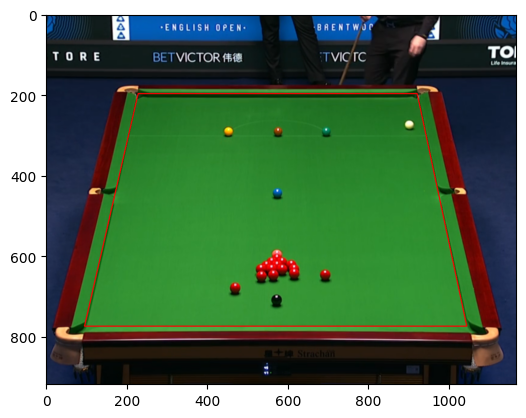

In [39]:
img = read_image_as_numpyimage(f'data/pics/{picname}')
ann = leaded_clean.filter_by_image(picname)

finder = PlayfieldFinder(img)
playfield = finder.detect_inner_playfield()

display_img(playfield.display_on_image(img))

In [40]:
finder = BallFinder(img, playfield)
bbox_result = finder.find_blue()

x, y, w, h = bbox_result.as_numpy.astype(int)

In [41]:
bac = BallAnnotationCollection.from_clean_file('data/ball_gt.json')
bbox_gt = bac.get_bboxes_by_color(picname, 'blue')
x_gt, y_gt, w_gt, h_gt = transform_bbox(finder.img, bbox_gt[0].as_numpy).astype(int)

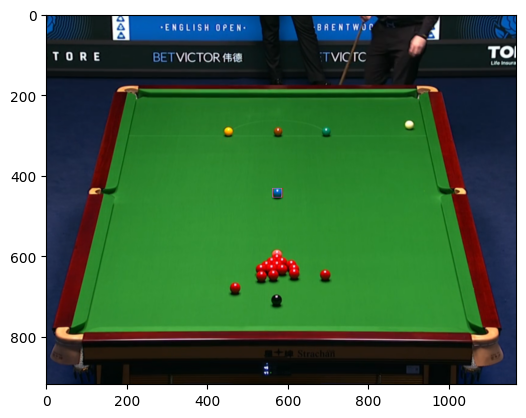

In [42]:
cv2.rectangle(finder.img, (x, y), (x + w, y + h), (255, 0, 0), thickness=1)
cv2.rectangle(finder.img, (x_gt, y_gt), (x_gt + w_gt, y_gt + h_gt), (255, 100, 255), thickness=1)

display_img(finder.img)

In [43]:
bbox_result = bbox_result.as_tensor.unsqueeze(0)

In [50]:
(21*22)/(26*22)

0.8076923076923077

In [44]:
bbox_gt = transform_bbox(finder.img, bbox_gt[0].as_numpy)
bbox_gt = torch.tensor(bbox_gt).unsqueeze(0)

In [45]:
bbox_result, bbox_gt

(tensor([[563., 432.,  24.,  22.]]), tensor([[561, 432,  23,  22]]))

In [46]:
box_iou(bbox_gt, bbox_result, fmt='xywh')

tensor([[0.8077]])